In [1]:
# conda activate chronocell

import os
import sys
import shap
import pandas as pd
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.inspection import PartialDependenceDisplay
from sklearn.metrics import mean_squared_error, r2_score


sys.path.append(os.path.abspath("/mnt/lareaulab/reliscu/projects/Chronocell/analyses/simulations/code"))

from protein_from_RNA import *

/mnt/lareaulab/reliscu/anaconda3/envs/chronocell/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ==== Transcription rate ====
alpha_mu = 2 # (Corresponds to ~7 mRNAs/hour, per Chronocell paper)
alpha_sd = 1

# === Splicing rate ===
beta_mu = 2 # np.log(splicing_rate) # (Corresponds to ~8.5 minute splicing rate, per Chronocell paper)
beta_sd = 0.5

# === mRNA degradation rate ===
gamma_mu = 0.5 # (Corresponds to ~2.8 hour half-life, per Chronocell paper)
gamma_sd = 0.5

# Simulate data

random_seed = 666 
n = 100 # No. cells per lineage
p = 5 # No. genes
topo = np.array([[0, 1, 2, 3]])
tau = (0, 2, 6, 8)

theta = get_RNA_params(topo, p, alpha_mu, alpha_sd, beta_mu, beta_sd, gamma_mu, gamma_sd, random_seed=random_seed)
Y_observed, Y, theta, rd, true_t, true_l = simulate_RNA(topo, tau, theta, n, random_seed=random_seed)

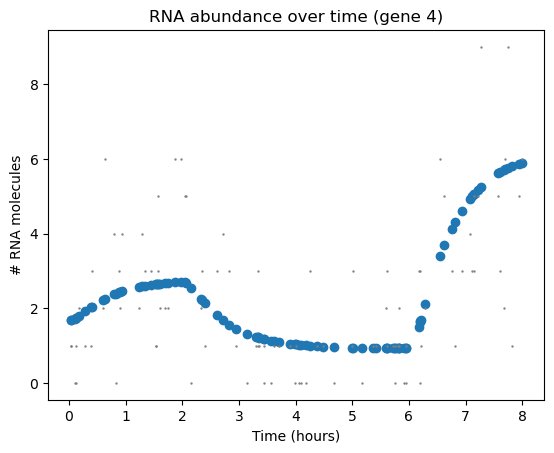

In [3]:
gene_idx = 4

# Plot example RNA trajectory

plt.scatter(true_t, Y[:, gene_idx, 1])
plt.scatter(true_t, Y_observed[:, gene_idx, 1], s=.5, color="gray")

plt.xlabel("Time (hours)");
plt.ylabel("# RNA molecules")
plt.title(f"RNA abundance over time (gene {gene_idx})");

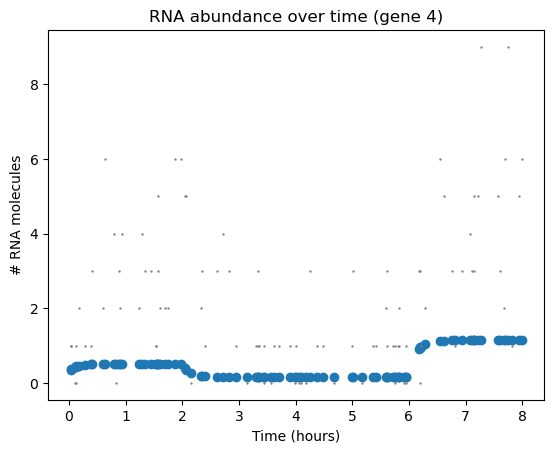

In [4]:
plt.scatter(true_t, Y[:, gene_idx, 0])
plt.scatter(true_t, Y_observed[:, gene_idx, 1], s=.5, color="gray")

plt.xlabel("Time (hours)");
plt.ylabel("# RNA molecules")
plt.title(f"RNA abundance over time (gene {gene_idx})");

In [5]:
cell_idx = np.argmax(true_t)

print(Y[cell_idx, gene_idx, 0])
print(Y[cell_idx, gene_idx, 1])

1.1409775197195768
5.899196865783884


In [6]:
# def backward_step(U_k, S_k, alpha, beta, gamma, dt):
#     eB = np.exp(-beta * dt)   # e^{-βΔ}
#     eG = np.exp(-gamma * dt)  # e^{-γΔ}

#     one_minus_eB_over_beta = -np.expm1(-beta * dt) / beta
#     one_minus_eG_over_gamma = -np.expm1(-gamma * dt) / gamma

#     d = (gamma - beta)
    
#     if np.abs(d) < 0:
#         print("np.abs(d) < 0")
     
#     cross = np.exp(-gamma * dt) * (np.expm1(d * dt) / d) # np.where(
#     #     np.abs(d) > 0,
#     #     np.exp(-gamma * dt) * (np.expm1(d * dt) / d),
#     #     dt * np.exp(-gamma * dt)
#     # )   
    
#     U_prev = np.maximum(0, (U_k - alpha * one_minus_eB_over_beta) / eB) 
#     S_prev = (S_k - beta * cross * U_prev - alpha * (one_minus_eG_over_gamma - cross)) / eG
    
#     return U_prev, S_prev

In [ ]:
import numpy as np

def backward_step(Uk, Sk, alpha, beta, gamma, dt):
    # steady states
    a_over_b = alpha / beta
    a_over_g = alpha / gamma

    # survival terms
    EB = np.exp(beta * dt)     # note: +beta in the centered form
    EG = np.exp(gamma * dt)

    # cross term C = (e^{-βΔ} - e^{-γΔ}) / (γ - β)  with smooth γ≈β limit
    d = gamma - beta
    C = np.where(
        np.abs(d) > 0,
        (np.exp(-beta*dt) - np.exp(-gamma*dt)) / d,
        dt * np.exp(-gamma*dt)
    )

    # centered, numerically stable inverses
    U_prev = a_over_b + (Uk - a_over_b) * EB
    S_prev = a_over_g + EG * (Sk - a_over_g - beta * C * (U_prev - a_over_b))
    return U_prev, S_prev



In [ ]:
def gridify_cell_state(tau, time_grid):
    state_grid = np.zeros(shape=time_grid.shape, dtype=int) 
    for k in range(1, len(tau)):  
        idx = (time_grid <= tau[k]) & (time_grid > tau[k-1])
        state_grid[idx] = k-1
    return state_grid

# Focus on 1 gene:

time_grid = true_t

theta_ = theta.copy()
alpha_ = theta_[gene_idx, :len(topo.flatten())] # Transcription rates
beta = theta_[gene_idx, -2] # Splicing rates
gamma = theta_[gene_idx, -1] # Degradation rates
alpha_ *= beta # These values were normalized by splicing rate for simulation function; removing this factor now
alpha = alpha_[1:len(alpha_)]

state_grid = np.searchsorted(tau, time_grid, side='right') - 1 # gridify_cell_state(tau, time_grid)

U = np.full(len(time_grid), np.nan, dtype=float)
S = np.full(len(time_grid), np.nan, dtype=float)

U[cell_idx] = Y[cell_idx, gene_idx, 0]
S[cell_idx] = Y[cell_idx, gene_idx, 1]

M = len(time_grid)
atol = 1e-15 
cell_idx = 99

for k in reversed(range(1, cell_idx + 1)):
    t_prev, t_curr = time_grid[k-1], time_grid[k]
    state_prev, state_curr = state_grid[k-1], state_grid[k]
    
    if state_prev == state_curr:
        dt = t_curr - t_prev
        alpha_k = alpha[state_curr]
        U[k-1], S[k-1] = backward_step_mp(U[k], S[k], alpha_k, beta, gamma, dt)
    else:
        # State switch happens between previous and current time point
        tau_ = tau[state_curr]
        
        # left_eq  = np.isclose(tau_, t_prev, atol=atol)
        # right_eq = np.isclose(tau_, t_curr, atol=atol)

        # if right_eq:
        #     dt1 = t_curr - t_prev
        #     if dt1 == 0:
        #         U[k-1], S[k-1] = U[k], S[k]
        #     else:
        #         U[k-1], S[k-1] = backward_step(U[k], S[k], alpha[state_prev], beta, gamma, dt1)
        # elif left_eq:
        #     dt2 = t_cur - t_prev
        #     if dt2 == 0:
        #         U[k-1], S[k-1] = U[k], S[k]
        #     else:
        #         U[k-1], S[k-1] = backward_step(U[k], S[k], alpha[state_curr], beta, gamma, dt2)
        # else: 
        
        # Split backward march into 2 steps:
        # tau < t_k
        dt2 = t_curr - tau_
        U_tau, S_tau = backward_step_mp(U[k], S[k], alpha[state_curr], beta, gamma, dt2)
        # t_k-1 < tau
        dt1 = tau_ - t_prev
        U[k-1], S[k-1] = backward_step_mp(U_tau, S_tau, alpha[state_prev], beta, gamma, dt1) 
        

In [74]:
S

array([2.42341387e+12, 2.24130635e+12, 1.36651292e+12, 1.08664807e+12,
       1.07027217e+12, 6.87974794e+11, 2.91183287e+11, 1.29977566e+11,
       1.18020280e+11, 2.33437864e+10, 1.77836283e+10, 4.65064674e+09,
       3.62054652e+09, 2.26751634e+09, 2.00297710e+09, 1.42037776e+09,
       1.40201536e+08, 8.19053780e+07, 5.59447735e+07, 2.24776095e+07,
       1.20269890e+07, 1.08905623e+07, 8.30597399e+06, 8.06444813e+06,
       6.74404592e+06, 3.08383259e+06, 1.93520781e+06, 7.01055553e+05,
       3.06989744e+05, 1.71959191e+05, 1.45464545e+05, 6.97704871e+04,
       1.70811893e+04, 1.57773373e+04, 1.06832239e+04, 1.90474698e+03,
       7.49057128e+02, 3.06820593e+02, 1.10366197e+02, 2.43029793e+01,
       7.43484975e+00, 6.28163390e+00, 5.84488612e+00, 5.28002437e+00,
       3.36778215e+00, 3.19694552e+00, 1.86274933e+00, 1.64422720e+00,
       1.32064369e+00, 1.10527510e+00, 1.06069044e+00, 1.05061455e+00,
       1.03630981e+00, 1.03019236e+00, 1.00997400e+00, 9.99719558e-01,
      

In [15]:
U

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.12560345,
       0.14826736, 0.15254064, 0.15785994, 0.15982778, 0.16483462,
       0.16646019, 0.16777304, 0.16826359, 0.16852708, 0.16859863,
       0.16859951, 0.16860311, 0.16860408, 0.16860414, 0.16860429,
       0.16860429, 0.16860429, 0.16860431, 0.16860431, 0.16860432,
       0.16860432, 0.16860432, 0.16860432, 0.16860432, 0.16860

In [14]:
np.where(np.abs(Y[:, gene_idx, 0] - U) > .01)

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
        34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
        51, 52]),)

In [16]:
idx = 52

In [19]:
Y[52:, gene_idx, 0]

array([0.16860434, 0.16860434, 0.16860433, 0.16860433, 0.16860433,
       0.16860433, 0.16860433, 0.16860433, 0.16860433, 0.16860433,
       0.16860433, 0.16860433, 0.16860433, 0.16860433, 0.16860433,
       0.16860433, 0.16860433, 0.16860433, 0.16860433, 0.16860433,
       0.16860433, 0.16860433, 0.16860433, 0.16860433, 0.8996119 ,
       0.94365794, 0.95262105, 0.96256143, 1.04865151, 1.1300379 ,
       1.1351215 , 1.138875  , 1.13969627, 1.14047835, 1.14082076,
       1.14086343, 1.14089045, 1.14089302, 1.14093017, 1.14094715,
       1.14097508, 1.14097567, 1.14097646, 1.14097668, 1.140977  ,
       1.14097727, 1.14097747, 1.14097752])

In [333]:
np.where(np.abs(S - Y[:, gene_idx, 1]) > 10)

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28]),)

In [21]:
start_idx = 1

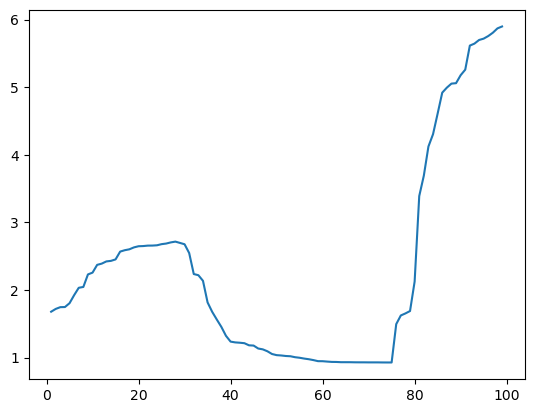

In [22]:
plt.plot(range(start_idx, cell_idx + 1), Y[start_idx:, gene_idx, 1])

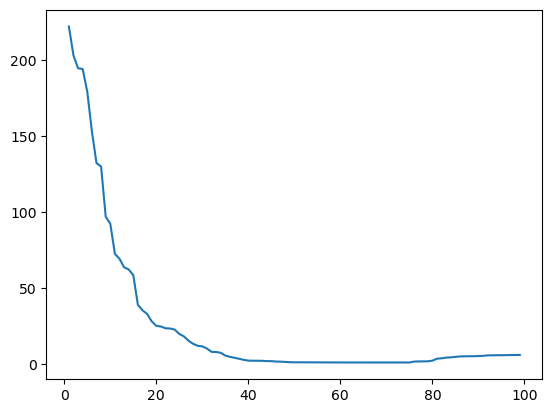

In [23]:
plt.plot(range(start_idx, cell_idx + 1), S[start_idx:])

In [ ]:
def forward_step_const_alpha(U_prev, S_prev, alpha, beta, gamma, dt):
    eB = np.exp(-beta * dt); eG = np.exp(-gamma * dt)
    one_minus_eB_over_beta  = -np.expm1(-beta  * dt) / beta
    one_minus_eG_over_gamma = -np.expm1(-gamma * dt) / gamma
    d = (gamma - beta)
    cross = np.where(np.abs(d) > 0,
                     np.exp(-gamma * dt) * (np.expm1(d * dt) / d),
                     dt * np.exp(-gamma * dt))
    U = eB * U_prev + alpha * one_minus_eB_over_beta
    S = eG * S_prev + beta * cross * U_prev + alpha * (one_minus_eG_over_gamma - cross)
    return U, S

def forward_step_interval(U_prev, S_prev, k, t, tau, alpha_state, atol=1e-12):
    t_prev, t_cur = t[k-1], t[k]
    s_prev = np.searchsorted(tau, t_prev, side='right') - 1
    s_cur  = np.searchsorted(tau, t_cur,  side='right') - 1
    if s_prev == s_cur:
        return forward_step_const_alpha(U_prev, S_prev, alpha_state[s_cur], beta, gamma, t_cur - t_prev)
    tau_c = tau[s_cur]
    if np.isclose(tau_c, t_prev, atol=atol):
        return forward_step_const_alpha(U_prev, S_prev, alpha_state[s_cur], beta, gamma, t_cur - t_prev)
    if np.isclose(tau_c, t_cur, atol=atol):
        return forward_step_const_alpha(U_prev, S_prev, alpha_state[s_prev], beta, gamma, t_cur - t_prev)
    U_mid, S_mid = forward_step_const_alpha(U_prev, S_prev, alpha_state[s_prev], beta, gamma, tau_c - t_prev)
    return forward_step_const_alpha(U_mid, S_mid, alpha_state[s_cur], beta, gamma, t_cur - tau_c)


In [51]:
def backward_step_const_alpha(U, S, alpha, beta, gamma, dt):
    eB = np.exp(-beta * dt)
    eG = np.exp(-gamma * dt)
    one_minus_eB_over_beta  = -np.expm1(-beta  * dt) / beta
    one_minus_eG_over_gamma = -np.expm1(-gamma * dt) / gamma
    d = (gamma - beta)
    cross = np.where(np.abs(d) > 0,
                     np.exp(-gamma * dt) * (np.expm1(d * dt) / d),
                     dt * np.exp(-gamma * dt))
    U_prev = (U - (alpha * one_minus_eB_over_beta)) / eB
    S_prev = (S - (beta * cross * U_prev + alpha * (one_minus_eG_over_gamma - cross))) / eG
    return U_prev, S_prev

def backward_step_interval(U, S, k, t, tau, alpha_state, atol=1e-12):
    t_prev, t_cur = t[k-1], t[k]
    s_prev = np.searchsorted(tau, t_prev, side='right') - 1
    s_cur  = np.searchsorted(tau, t_cur,  side='right') - 1
    if s_prev == s_cur:
        return backward_step_const_alpha(U, S, alpha_state[s_cur], beta, gamma, t_cur - t_prev)
    else:
        tau_c = tau[s_cur]
        U_mid, S_mid = backward_step_const_alpha(U, S, alpha_state[s_prev], beta, gamma, t_cur - tau_c)
        return backward_step_const_alpha(U_mid, S_mid, alpha_state[s_cur], beta, gamma, tau_c - t_prev)
      
    # if np.isclose(tau_c, t_prev, atol=atol):
    #     return backward_step_const_alpha(U_prev, S_prev, alpha_state[s_cur], beta, gamma, t_cur - t_prev)
    # if np.isclose(tau_c, t_cur, atol=atol):
    #     return backward_step_const_alpha(U_prev, S_prev, alpha_state[s_prev], beta, gamma, t_cur - t_prev)

In [ ]:
from mpmath import mp


In [68]:
import numpy as np
print(np.finfo(np.longdouble))

def estimate_dps(beta, t):
    T = float(t[-1] - t[0])
    return int(np.ceil(beta * T / np.log(10.0))) + 10

Machine parameters for float128
---------------------------------------------------------------
precision =  18   resolution = 1e-18
machep =    -63   eps =        1.084202172485504434e-19
negep =     -64   epsneg =     5.42101086242752217e-20
minexp = -16382   tiny =       3.3621031431120935063e-4932
maxexp =  16384   max =        1.189731495357231765e+4932
nexp =       15   min =        -max
smallest_normal = 3.3621031431120935063e-4932   smallest_subnormal = 4e-4951
---------------------------------------------------------------



In [ ]:
K = len(tau) - 1
theta_ = theta.copy()
beta  = theta[gene_idx, -2]
gamma = theta[gene_idx, -1]

a_over_beta = theta[gene_idx, 1:K+1]
alpha_state = a_over_beta * beta         
t = true_t

In [ ]:
U = np.full(len(time_grid), np.nan, dtype=float)
S = np.full(len(time_grid), np.nan, dtype=float)

U[cell_idx] = Y[cell_idx, gene_idx, 0]
S[cell_idx] = Y[cell_idx, gene_idx, 1]

M = len(time_grid)
atol = 1e-15 
cell_idx = 99

for k in reversed(range(1, cell_idx + 1)):
    U[k-1], S[k-1] = backward_step_interval(U[k], S[k], k, t, tau, alpha_state)

In [63]:
import numpy as np

def _cross_term(beta, gamma, dt):
    # C = (e^{-βΔ} - e^{-γΔ}) / (γ - β), with smooth γ≈β limit
    d = gamma - beta
    return np.where(
        np.abs(d) > 0,
        np.exp(-gamma*dt) * (np.expm1(d*dt) / d),   # e^{-γΔ} * (e^{(γ-β)Δ}-1)/(γ-β)
        dt * np.exp(-gamma*dt)
    )

def backward_step(Uk, Sk, alpha, beta, gamma, dt):
    # centered, numerically stable inverses
    a_over_b = alpha / beta
    a_over_g = alpha / gamma
    EB = np.exp(beta * dt)     # backward multiplier for U
    EG = np.exp(gamma * dt)    # backward multiplier for S
    C  = _cross_term(beta, gamma, dt)
    U_prev = a_over_b + (Uk - a_over_b) * EB
    S_prev = a_over_g + EG * (Sk - a_over_g - beta * C * (U_prev - a_over_b))
    return U_prev, S_prev

def forward_step_const_alpha(U_prev, S_prev, alpha, beta, gamma, dt):
    eB = np.exp(-beta*dt); eG = np.exp(-gamma*dt)
    one_minus_eB_over_beta  = -np.expm1(-beta  * dt) / beta
    one_minus_eG_over_gamma = -np.expm1(-gamma * dt) / gamma
    C  = _cross_term(beta, gamma, dt)
    U = eB * U_prev + alpha * one_minus_eB_over_beta
    S = eG * S_prev + beta * C * U_prev + alpha * (one_minus_eG_over_gamma - C)
    return U, S

def backward_pass_timepoint_alpha(U_last, S_last, t, tau, alpha_state, beta, gamma, start_idx=None, atol=1e-12):
    t = np.asarray(t); K = len(tau)-1
    assert alpha_state.shape == (K,), f"alpha_state must be length {K}, got {alpha_state.shape}"

    if start_idx is None: start_idx = len(t)-1

    # Right-closed: τ_j < t_i ≤ τ_{j+1}
    state_grid = np.searchsorted(tau, t, side='right') - 1
    alpha_grid = alpha_state[state_grid]

    U = np.full(len(t), np.nan); S = np.full(len(t), np.nan)
    U[start_idx] = U_last; S[start_idx] = S_last

    for k in range(start_idx, 0, -1):
        t_prev, t_cur = t[k-1], t[k]
        s_prev, s_cur = state_grid[k-1], state_grid[k]

        if s_prev == s_cur:
            U[k-1], S[k-1] = backward_step(U[k], S[k], alpha_grid[k], beta, gamma, t_cur - t_prev)
        else:
            # cross exactly at τ_c
            assert s_cur == s_prev + 1, "multiple boundaries crossed in one step"
            tau_c = tau[s_cur]
            if np.isclose(tau_c, t_prev, atol=atol):
                U[k-1], S[k-1] = backward_step(U[k], S[k], alpha_state[s_cur], beta, gamma, t_cur - t_prev)
            elif np.isclose(tau_c, t_cur, atol=atol):
                U[k-1], S[k-1] = backward_step(U[k], S[k], alpha_state[s_prev], beta, gamma, t_cur - t_prev)
            else:
                U_tau, S_tau   = backward_step(U[k],   S[k],   alpha_state[s_cur],  beta, gamma, t_cur - tau_c)
                U[k-1], S[k-1] = backward_step(U_tau, S_tau, alpha_state[s_prev], beta, gamma, tau_c - t_prev)
    return U, S

def forward_step_interval(U_prev, S_prev, k, t, tau, alpha_state, beta, gamma, atol=1e-12):
    t_prev, t_cur = t[k-1], t[k]
    s_prev = np.searchsorted(tau, t_prev, side='right') - 1
    s_cur  = np.searchsorted(tau, t_cur,  side='right') - 1
    if s_prev == s_cur:
        return forward_step_const_alpha(U_prev, S_prev, alpha_state[s_cur], beta, gamma, t_cur - t_prev)
    tau_c = tau[s_cur]
    if np.isclose(tau_c, t_prev, atol=atol):
        return forward_step_const_alpha(U_prev, S_prev, alpha_state[s_cur], beta, gamma, t_cur - t_prev)
    if np.isclose(tau_c, t_cur, atol=atol):
        return forward_step_const_alpha(U_prev, S_prev, alpha_state[s_prev], beta, gamma, t_cur - t_prev)
    U_mid, S_mid = forward_step_const_alpha(U_prev, S_prev, alpha_state[s_prev], beta, gamma, tau_c - t_prev)
    return forward_step_const_alpha(U_mid, S_mid, alpha_state[s_cur], beta, gamma, t_cur - tau_c)

def first_mismatch(U, S, Y, t, tau, alpha_state, beta, gamma, rtol=1e-11, atol=1e-12):
    # Check recursion against forward map AND simulator means Y at every k
    for k in reversed(range(1, len(t))):
        Uf, Sf = forward_step_interval(U[k-1], S[k-1], k, t, tau, alpha_state, beta, gamma)
        # if not (np.allclose(Uf, U[k], rtol=rtol, atol=atol) and np.allclose(Sf, S[k], rtol=rtol, atol=atol)):
        #     return ("forward/backward mismatch", k, Uf, U[k], Sf, S[k])
        if not (np.allclose(U[k], Y[k, 0], rtol=rtol, atol=atol) and np.allclose(S[k], Y[k, 1], rtol=rtol, atol=atol)):
            return ("vs-simulator mismatch", k, Y[k, 0], U[k], Y[k, 1], S[k])
    return ("ok", None, None, None, None, None)



In [64]:
# Build per-STATE α (NOT per-timepoint)
K = len(tau) - 1
beta  = float(theta[gene_idx, -2])
gamma = float(theta[gene_idx, -1])
a_over_beta = theta[gene_idx, 1:K+1]     # columns 1..K  (α/β)
alpha_state = a_over_beta * beta          # shape (K,)

# terminal (noise-free) means
idxT = len(time_grid) - 1
U_T = float(Y[idxT, gene_idx, 0])
S_T = float(Y[idxT, gene_idx, 1])

U, S = backward_pass_timepoint_alpha(U_T, S_T, time_grid, tau, alpha_state, beta, gamma, start_idx=idxT)

kind, k, x1, x2, y1, y2 = first_mismatch(U, S, Y[:, gene_idx, :], time_grid, tau, alpha_state, beta, gamma)
print("check:", kind, "at k=", k)
if kind == "ok":
    ok = ~np.isnan(U)
    print("max |ΔU| =", np.max(np.abs(U[ok] - Y[:, gene_idx, 0][ok])),
          "max |ΔS| =", np.max(np.abs(S[ok] - Y[:, gene_idx, 1][ok])))


check: vs-simulator mismatch at k= 91


In [65]:
first_mismatch(U, S, Y[:, gene_idx, :], time_grid, tau, alpha_state, beta, gamma)

('vs-simulator mismatch',
 91,
 np.float64(1.1409471477800635),
 np.float64(1.1409471477800155),
 np.float64(5.260166523495448),
 np.float64(5.260166523388571))

In [ ]:
import numpy as np

def closed_form_single_gene(t, tau, a0_over_beta, a_over_beta, beta, gamma):
    """
    Exact E[U], E[S] for one gene under piecewise-constant α.
    - a0_over_beta = alpha0 / beta  (theta[gene, 0])
    - a_over_beta  = [alpha1/beta, ..., alphaK/beta]  (length K)
    """
    t = np.asarray(t)
    K = len(tau) - 1
    assert len(a_over_beta) == K

    eBt = np.exp(-beta * t)
    eGt = np.exp(-gamma * t)

    # U(t)
    U = a0_over_beta * eBt.copy()
    for k in range(1, K + 1):
        Ik  = (t > tau[k])                      # t > tau_k
        idx = (t > tau[k-1]) & (~Ik)            # tau_{k-1} < t <= tau_k
        ak  = a_over_beta[k-1]                  # alpha_k / beta

        U += ak * (np.exp(-beta * (t - tau[k])) - np.exp(-beta * (t - tau[k-1]))) * Ik
        U += ak * (1.0 - np.exp(-beta * (t - tau[k-1]))) * idx

    # S(t) via same constants used in the simulator
    c = beta / (beta - gamma)
    d = (beta**2) / ((beta - gamma) * gamma)
    S = d * a0_over_beta * eGt.copy()
    for k in range(1, K + 1):
        Ik  = (t > tau[k])
        idx = (t > tau[k-1]) & (~Ik)
        ak  = a_over_beta[k-1]
        S  += d * ak * (np.exp(-gamma * (t - tau[k])) - np.exp(-gamma * (t - tau[k-1]))) * Ik
        S  += d * ak * (1.0 - np.exp(-gamma * (t - tau[k-1]))) * idx

    S = S - c * U
    return U, S

def _cross_term(beta, gamma, dt):
    # C = (e^{-βΔ} - e^{-γΔ}) / (γ - β), with smooth γ≈β limit
    d = gamma - beta
    return np.where(
        np.abs(d) > 0,
        np.exp(-gamma*dt) * (np.expm1(d*dt) / d),
        dt * np.exp(-gamma*dt)
    )

def backward_step_centered(Uk, Sk, alpha, beta, gamma, dt):
    # centered (around α/β and α/γ) to avoid big-minus-big cancellation
    a_over_b = alpha / beta
    a_over_g = alpha / gamma
    EB = np.exp(beta  * dt)          # backward multiplier for U
    EG = np.exp(gamma * dt)          # backward multiplier for S
    C  = _cross_term(beta, gamma, dt)

    U_prev = a_over_b + (Uk - a_over_b) * EB
    S_prev = a_over_g + EG * (Sk - a_over_g - beta * C * (U_prev - a_over_b))
    return U_prev, S_prev

def choose_anchors(t, tau, beta, kappa=10.0):
    """
    Return a sorted list of anchor indices:
      - always include last time index and index 0
      - include every τ boundary (mapped to the first t >= τ_j)
      - insert extra anchors so that each block length <= kappa/beta
    """
    t = np.asarray(t)
    M = len(t) - 1
    dt_max = kappa / float(beta)

    # Start with taus mapped to time indices (skip tau[0], tau[-1] outside range typically)
    tau_idxs = []
    for j in range(1, len(tau)-1):
        k_tau = int(np.searchsorted(t, tau[j], side='left'))  # first t >= tau_j
        if 0 <= k_tau <= M:
            tau_idxs.append(k_tau)

    anchors = set([0, M] + tau_idxs)

    # Enforce max block length by dropping extra anchors backward
    anchors = sorted(anchors)
    out = [anchors[-1]]
    for i in range(len(anchors)-1, 0, -1):
        hi = anchors[i]
        lo = anchors[i-1]
        # subdivide [lo, hi] if too long
        while t[hi] - t[lo] > dt_max:
            # place an interior anchor at time t[hi] - dt_max
            target_t = t[hi] - dt_max
            k = int(np.searchsorted(t, target_t, side='left'))
            if k <= lo:  # can't go further; break to avoid infinite loop
                break
            out.append(k)
            hi = k
        out.append(lo)
    return sorted(set(out))

def reanchored_backward(U_T, S_T, t, tau, alpha_state, beta, gamma, kappa=10.0):
    """
    Re-anchored backward pass:
      - alpha_state: per-STATE α, length K (for intervals (τ_j, τ_{j+1}])
      - Uses right-closed state assignment (τ_j < t_i ≤ τ_{j+1})
      - Anchors at τ boundaries and interior points so that each block
        has length <= kappa/beta.
    """
    t = np.asarray(t)
    K = len(tau) - 1
    assert len(alpha_state) == K

    # per-timepoint state and α (right-closed)
    state_grid = np.searchsorted(tau, t, side='right') - 1
    alpha_grid = alpha_state[state_grid]

    # closed-form at all times (to re-anchor)
    a0_over_beta = None  # recover from alpha_state & theta if you have it; else pass explicitly
    # we can recover a0_over_beta from your theta outside this function and pass it in.
    # To keep the function self-contained, we'll compute a_over_beta from alpha_state and require a0_over_beta as arg.

    raise_if_missing = """
    Please compute a0_over_beta = theta[gene_idx, 0] (that's alpha0/beta in your simulator)
    and call reanchored_backward_with_a0 below instead (it wraps this function).
    """
    return raise_if_missing

def reanchored_backward_with_theta(U_T, S_T, t, tau, theta_row, kappa=10.0):
    """
    theta_row: theta[gene_idx, :] from your simulator
       layout: [a0_over_beta, a1_over_beta, ..., aK_over_beta, beta, gamma]
    """
    K = len(tau) - 1
    a0_over_beta = float(theta_row[0])
    a_over_beta  = theta_row[1:K+1].astype(float)
    beta  = float(theta_row[-2])
    gamma = float(theta_row[-1])
    alpha_state = a_over_beta * beta

    # exact closed form at anchors
    U_cf, S_cf = closed_form_single_gene(t, tau, a0_over_beta, a_over_beta, beta, gamma)

    # anchors
    anchors = choose_anchors(t, tau, beta, kappa=kappa)

    # prep arrays and state/alpha grids
    state_grid = np.searchsorted(tau, t, side='right') - 1
    alpha_grid = alpha_state[state_grid]

    U = np.full_like(t, np.nan, dtype=float)
    S = np.full_like(t, np.nan, dtype=float)

    # Start from the last anchor: force to closed form (ignore U_T,S_T mismatch if any)
    U[anchors[-1]] = U_cf[anchors[-1]]
    S[anchors[-1]] = S_cf[anchors[-1]]

    # walk blocks right → left
    for i in range(len(anchors)-1, 0, -1):
        hi = anchors[i]
        lo = anchors[i-1]

        # ensure exact anchor at the right boundary
        U[hi], S[hi] = U_cf[hi], S_cf[hi]

        # invert within (lo, hi]
        for k in range(hi, lo, -1):
            t_prev, t_cur = t[k-1], t[k]
            s_prev, s_cur = state_grid[k-1], state_grid[k]
            if s_prev == s_cur:
                U[k-1], S[k-1] = backward_step(U[k], S[k], alpha_grid[k], beta, gamma, t_cur - t_prev)
            else:
                # split exactly at τ_c
                tau_c = tau[s_cur]
                if np.isclose(tau_c, t_prev, atol=1e-12):
                    U[k-1], S[k-1] = backward_step(U[k], S[k], alpha_state[s_cur], beta, gamma, t_cur - t_prev)
                elif np.isclose(tau_c, t_cur, atol=1e-12):
                    U[k-1], S[k-1] = backward_step(U[k], S[k], alpha_state[s_prev], beta, gamma, t_cur - t_prev)
                else:
                    U_tau, S_tau   = backward_step(U[k], S[k], alpha_state[s_cur],  beta, gamma, t_cur - tau_c)
                    U[k-1], S[k-1] = backward_step(U_tau, S_tau, alpha_state[s_prev], beta, gamma, tau_c - t_prev)

        # snap (re-anchor) exactly at the left boundary of the block
        U[lo], S[lo] = U_cf[lo], S_cf[lo]

    return U, S, anchors, (U_cf, S_cf)


In [112]:
# pick a gene
g = 4
theta_row = theta[g, :]          # your simulator's per-gene parameter row

# terminal (noise-free) means
idxT = len(true_t) - 1
U_T, S_T = Y[idxT, g, 0], Y[idxT, g, 1]

# Run re-anchored backward; set kappa (e.g., 10 ⇒ per-block amp ≤ e^{10} ≈ 22k)
U_hat, S_hat, anchors, (U_cf, S_cf) = reanchored_backward_with_theta(
    U_T, S_T, true_t, tau, theta_row, kappa=100
)

# Inspect error
mask = ~np.isnan(U_hat)
print("max |ΔU| =", np.max(np.abs(U_hat[mask] - Y[:, g, 0][mask])))
print("max |ΔS| =", np.max(np.abs(S_hat[mask] - Y[:, g, 1][mask])))
print("anchors (indices):", anchors)


max |ΔU| = 0.037770760573706874
max |ΔS| = 0.046233283124253344
anchors (indices): [0, 29, 76, 99]


In [110]:
U_hat

array([0.35145159, 0.36337622, 0.42065879, 0.43898469, 0.440057  ,
       0.46509031, 0.49107272, 0.50162867, 0.50241165, 0.50861118,
       0.50897527, 0.50983523, 0.50990268, 0.50999128, 0.5100086 ,
       0.51004675, 0.51013058, 0.5101344 , 0.5101361 , 0.51013829,
       0.51013897, 0.51013905, 0.51013922, 0.51013923, 0.51013932,
       0.51013956, 0.51013964, 0.51013972, 0.51013974, 0.3913008 ,
       0.31921753, 0.240843  , 0.18628811, 0.1849381 , 0.17966367,
       0.17057465, 0.16937817, 0.16892039, 0.1687171 , 0.16862812,
       0.16861074, 0.16860956, 0.16860912, 0.16860854, 0.16860659,
       0.16860642, 0.16860508, 0.16860487, 0.16860456, 0.16860438,
       0.16860435, 0.16860435, 0.16860434, 0.16860434, 0.16860433,
       0.16860433, 0.16860433, 0.16860433, 0.16860433, 0.16860433,
       0.16860433, 0.16860433, 0.16860433, 0.16860433, 0.16860433,
       0.16860433, 0.16860433, 0.16860433, 0.16860433, 0.16860433,
       0.16860433, 0.16860433, 0.16860433, 0.16860433, 0.16860